**Importações Iniciais**

In [ ]:
# Importações de visualização
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import os

# Importação do Dataset - Google Drive
from google.colab import files

In [ ]:
try:
  df = pd.read_csv('train.csv', engine='python', on_bad_lines='skip')
except:
  baixados = files.upload()
  os.rename(list(baixados.keys()[0]), 'train.csv')

  df = pd.read_csv('train.csv', engine='python', on_bad_lines='skip')

# o arquivo 'train.csv' possui algumas linhas com erros de aspas não fechadas
# engine='python': Usado porque o motor padrão em C, travou ao encontrar esses erros.
# on_bad_lines='skip': Ignora as linhas problemáticas (~14 linhas) para garantir o carregamento
# do restante do dataset (~22.800 linhas) sem comprometer a estrutura das colunas.

In [ ]:
# Analisando se o carregamento foi correto
df.head(5)

,id,title,text,subject,date,label
0,13355,"Exclusive: Pentagon, Lockheed near deal on $9 ...",WASHINGTON (Reuters) - The U.S. Department of ...,politicsNews,"January 19, 2017",0
1,2113,“HILL”ARIOUS…MUST SEE! IOWA PARADE GOERS Treat...,HILL larious! If this was a Donald Trump pi a...,left-news,"Aug 3, 2016",1
2,27667,Philippine leader says 'no way' he'll do deal ...,MANILA (Reuters) - Philippine President Rodrig...,worldnews,"September 9, 2017",0
3,15368,Biden asks U.S. Congress to allow unencumbered...,WASHINGTON (Reuters) - Vice President Joe Bide...,politicsNews,"September 8, 2016",0
4,6934,Trump Claims ‘Any Negative Polls’ Are ‘FAKE N...,Donald Trump kicked off his Monday morning by ...,News,"February 6, 2017",1


In [ ]:
print(f'O numero de linhas foram: {df.shape[0]} linhas e o numero de colunas foram {df.shape[1]} colunas')

O numero de linhas foram: 22844 linhas e o numero de colunas foram 6 colunas


TRATANDO OS DADOS

In [ ]:
df.isnull().sum()

,0
id,0
title,0
text,0
subject,0
date,0
label,0


Sem valores nulos, entao nao precisamos fazer inputação

In [ ]:
print(f'Temos no total {df.duplicated().sum()} linhas duplicadas')

Temos no total 0 linhas duplicadas


Não temos duplicatas, então não precisamos tratá-las

In [ ]:
sns.set_style("whitegrid")
plt.figure(figsize=(15, 12))

<Figure size 1500x1200 with 0 Axes>

<Figure size 1500x1200 with 0 Axes>

#**GRÁFICO 1: DISTRIBUIÇÃO**

/tmp/ipython-input-3021931458.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.countplot(x='label', data=df, palette='viridis')


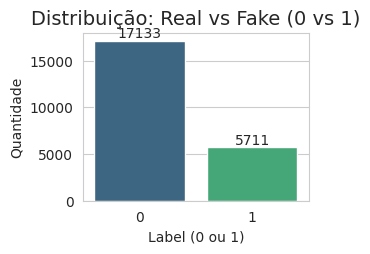

In [ ]:
plt.subplot(2, 2, 1)
ax1 = sns.countplot(x='label', data=df, palette='viridis')
plt.title('Distribuição: Real vs Fake (0 vs 1)', fontsize=14)
plt.xlabel('Label (0 ou 1)')
plt.ylabel('Quantidade')
# Adiciona os números em cima das barras
for container in ax1.containers:
    ax1.bar_label(container)

#**GRÁFICO 2: NOTÍCIAS FAKES**

/tmp/ipython-input-2881759480.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipython-input-2881759480.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


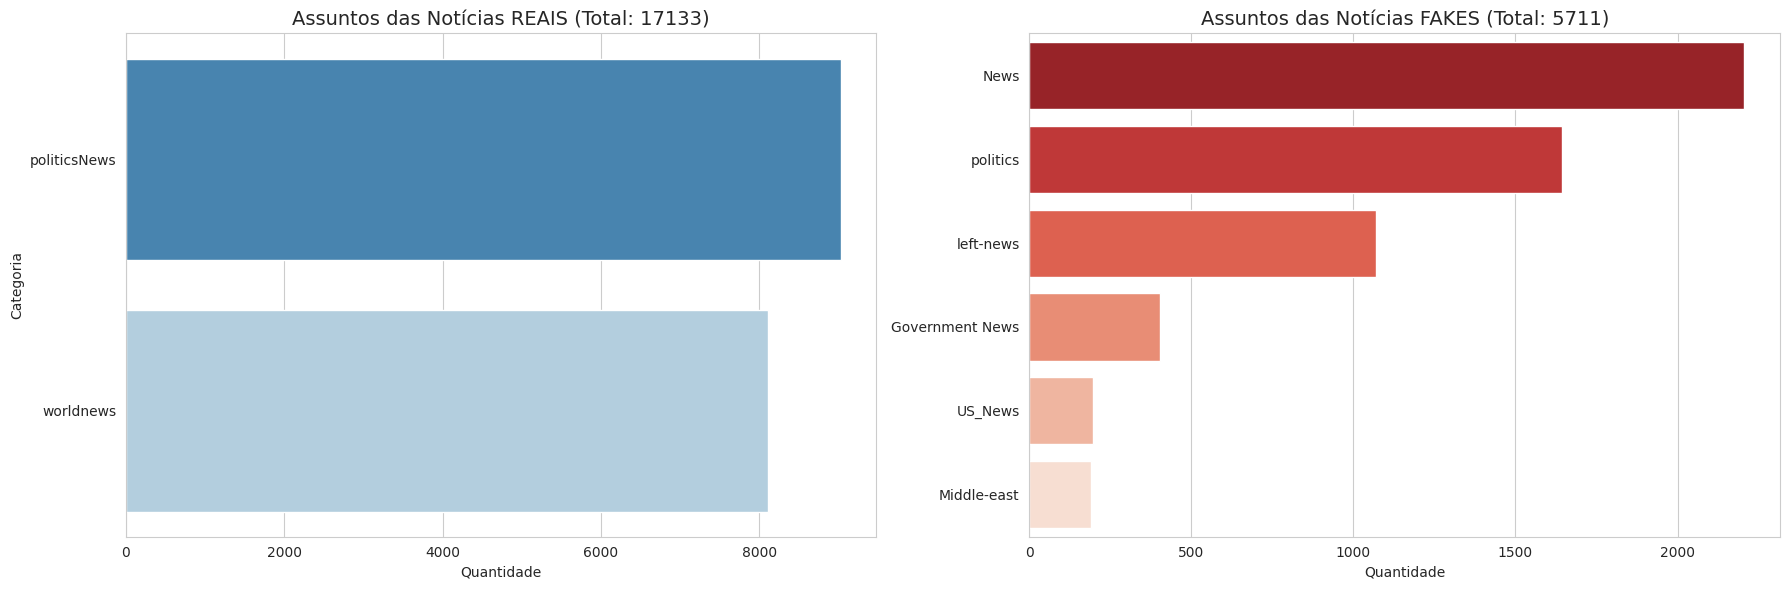

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

df_real = df[df['label'] == 0]
sns.countplot(
    y='subject',
    data=df_real,
    ax=axes[0],
    palette='Blues_r',
    order=df_real['subject'].value_counts().index # Ordena do maior para o menor
)
axes[0].set_title(f'Assuntos das Notícias REAIS (Total: {len(df_real)})', fontsize=14)
axes[0].set_xlabel('Quantidade')
axes[0].set_ylabel('Categoria')

df_fake = df[df['label'] == 1]
sns.countplot(
    y='subject',
    data=df_fake,
    ax=axes[1],
    palette='Reds_r', # Paleta Vermelha para "alerta"
    order=df_fake['subject'].value_counts().index # Ordena do maior para o menor
)
axes[1].set_title(f'Assuntos das Notícias FAKES (Total: {len(df_fake)})', fontsize=14)
axes[1].set_xlabel('Quantidade')
axes[1].set_ylabel('') # Tira o label Y do segundo pra não poluir

plt.tight_layout()
plt.show()

#**GRÁFICO 3: TAMANHO DO TEXTO**

/tmp/ipython-input-1806680884.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y='text_length', data=df, palette='coolwarm', showfliers=False)


Text(0, 0.5, 'Número de Caracteres')

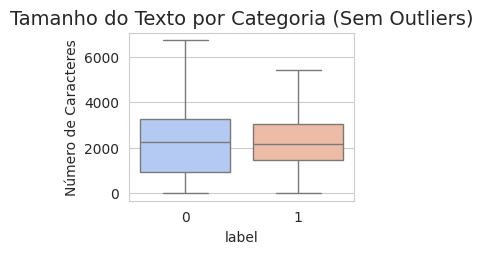

In [ ]:
# Coluna nova que conta o número de caracteres em cada notícia
df['text_length'] = df['text'].astype(str).apply(len)

# Vamos ver se notícias falsas (1) têm tamanhos diferentes das reais (0)
plt.subplot(2, 2, 3)
sns.boxplot(x='label', y='text_length', data=df, palette='coolwarm', showfliers=False)
# showfliers=False esconde os pontos muito fora da curva para o gráfico ficar legível
plt.title('Tamanho do Texto por Categoria (Sem Outliers)', fontsize=14)
plt.ylabel('Número de Caracteres')

In [ ]:
print("="*40)
print("RESUMO RÁPIDO DA EDA")
print("="*40)
print(f"1. Total de Linhas Carregadas: {df.shape[0]}")
print(f"2. Total de Colunas: {df.shape[1]}")
print("-" * 20)
print("3. Dados Faltantes (Nulos) por coluna:")
print(df.isnull().sum())
print("-" * 20)
print("4. Estatísticas do Tamanho do Texto (Média):")
print(df.groupby('label')['text_length'].mean())
print("="*40)

RESUMO RÁPIDO DA EDA
1. Total de Linhas Carregadas: 22844
2. Total de Colunas: 7
--------------------
3. Dados Faltantes (Nulos) por coluna:
id             0
title          0
text           0
subject        0
date           0
label          0
text_length    0
dtype: int64
--------------------
4. Estatísticas do Tamanho do Texto (Média):
label
0    2394.55682
1    2560.36596
Name: text_length, dtype: float64
